<a href="https://colab.research.google.com/github/nausahadali/Python-Basic-to-Advance/blob/main/Assignment1_Using_KNN_on_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine, make_classification, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay, r2_score, mean_squared_error
)

In [61]:
iris = load_iris()

In [62]:
X_iris = iris.data
y_iris = iris.target

In [63]:
target_names = iris.target_names
feature_names = iris.feature_names

In [64]:
df_iris = pd.DataFrame(X_iris, columns=feature_names)

In [65]:
df_iris['Species'] = [target_names[i] for i in y_iris]

In [66]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [67]:
df_iris.corr(numeric_only=True)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


In [68]:
X = df_iris.drop(['Species'], axis=1)
y = df_iris['Species']

In [69]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [70]:
X.isna().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [71]:
y.isna().sum()

np.int64(0)

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
model = KNeighborsClassifier(n_neighbors=3)

In [74]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [75]:
pred = model.predict(X_test)

In [76]:
acc = accuracy_score( y_test, pred)

In [77]:
acc

1.0

In [78]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred_k_5 = model.predict(X_test)
acc = accuracy_score(y_test, y_pred_k_5)
acc
print(classification_report(y_test, y_pred_k_5, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



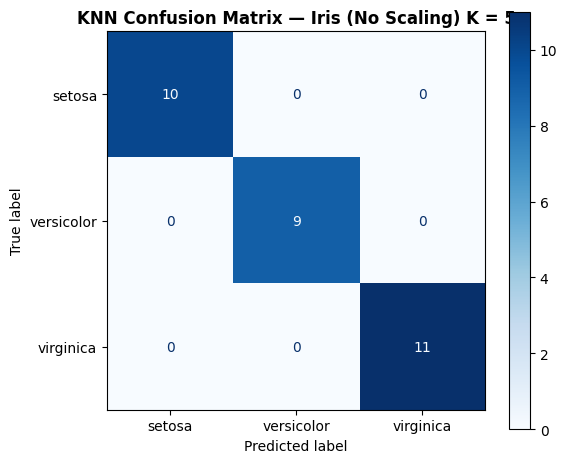

In [79]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_k_5)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('KNN Confusion Matrix — Iris (No Scaling) K = 5', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [80]:
model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train, y_train)
y_pred_k_7 = model.predict(X_test)
acc = accuracy_score(y_test, y_pred_k_7)
acc
print(classification_report(y_test, y_pred_k_7, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



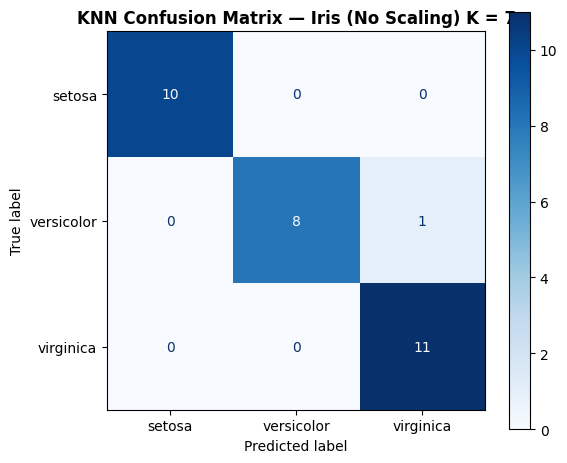

In [81]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_k_7)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('KNN Confusion Matrix — Iris (No Scaling) K = 7', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [82]:
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)
y_pred_k_9 = model.predict(X_test)
acc = accuracy_score(y_test, y_pred_k_9)
acc
print(classification_report(y_test, y_pred_k_9, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



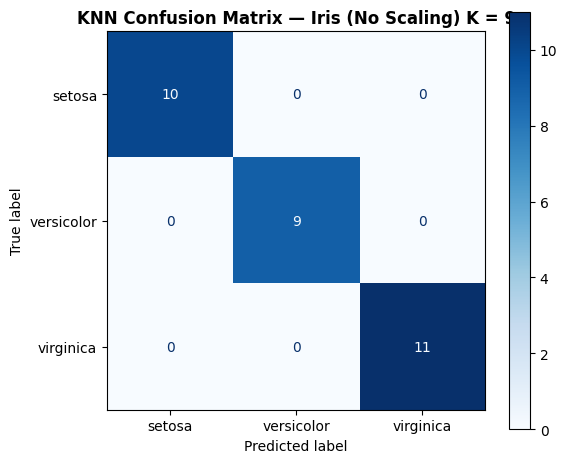

In [83]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_k_9)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('KNN Confusion Matrix — Iris (No Scaling) K = 9', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [84]:
model = KNeighborsClassifier(n_neighbors=11)
model.fit(X_train, y_train)
y_pred_k_11 = model.predict(X_test)
acc = accuracy_score(y_test, y_pred_k_11)
acc
print(classification_report(y_test, y_pred_k_11, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



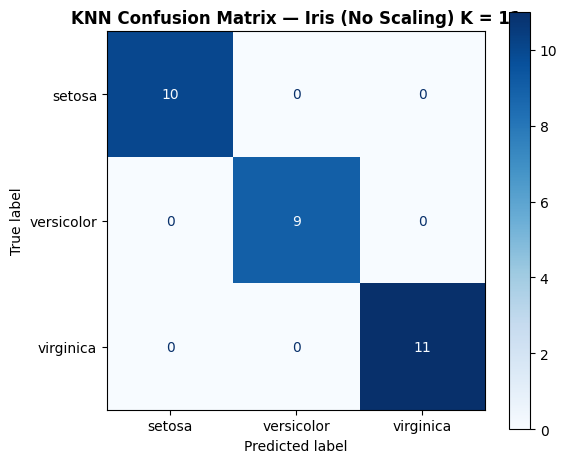

In [85]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_k_11)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('KNN Confusion Matrix — Iris (No Scaling) K = 11', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# With Scaling

In [86]:
scaler = StandardScaler()

In [87]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
y_pred_k_3 = model.predict(X_test)
acc = accuracy_score(y_test, y_pred_k_3)
acc
print(classification_report(y_test, y_pred_k_3, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



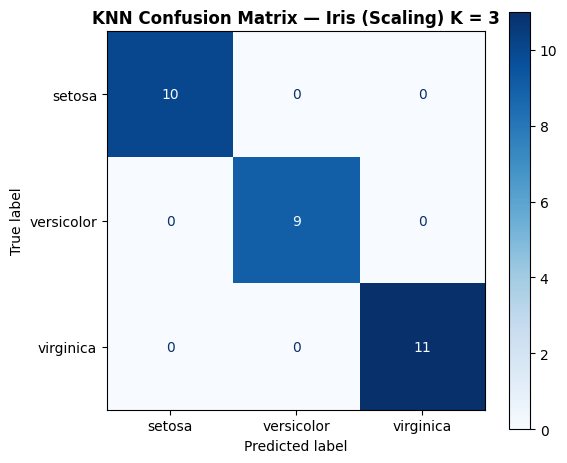

In [93]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_k_3)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('KNN Confusion Matrix — Iris (Scaling) K = 3', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [90]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred_k_5 = model.predict(X_test)
acc = accuracy_score(y_test, y_pred_k_5)
acc
print(classification_report(y_test, y_pred_k_5, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



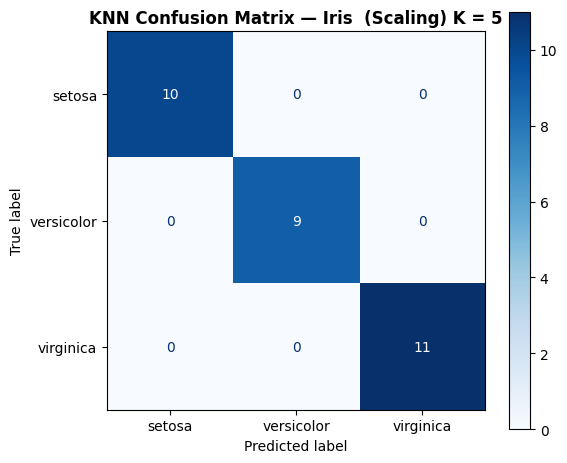

In [92]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_k_5)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('KNN Confusion Matrix — Iris  (Scaling) K = 5', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [94]:
model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train, y_train)
y_pred_k_7 = model.predict(X_test)
acc = accuracy_score(y_test, y_pred_k_7)
acc
print(classification_report(y_test, y_pred_k_7, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



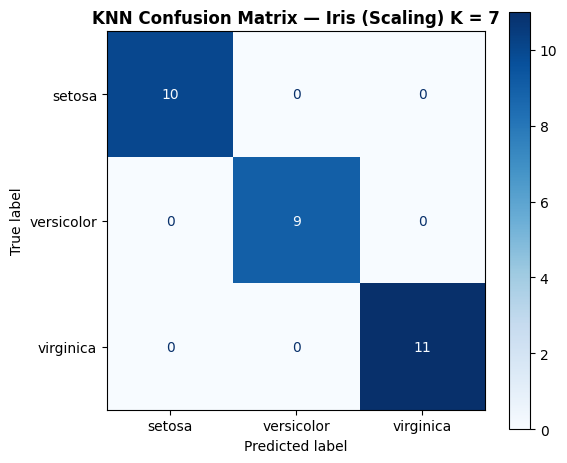

In [95]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_k_7)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('KNN Confusion Matrix — Iris (Scaling) K = 7', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [96]:
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)
y_pred_k_9 = model.predict(X_test)
acc = accuracy_score(y_test, y_pred_k_9)
acc
print(classification_report(y_test, y_pred_k_9, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



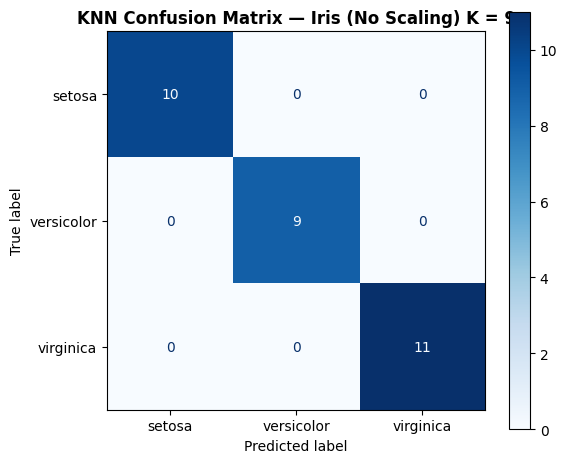

In [97]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_k_9)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('KNN Confusion Matrix — Iris (No Scaling) K = 9', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [98]:
model = KNeighborsClassifier(n_neighbors=11)
model.fit(X_train, y_train)
y_pred_k_11 = model.predict(X_test)
acc = accuracy_score(y_test, y_pred_k_11)
acc
print(classification_report(y_test, y_pred_k_11, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



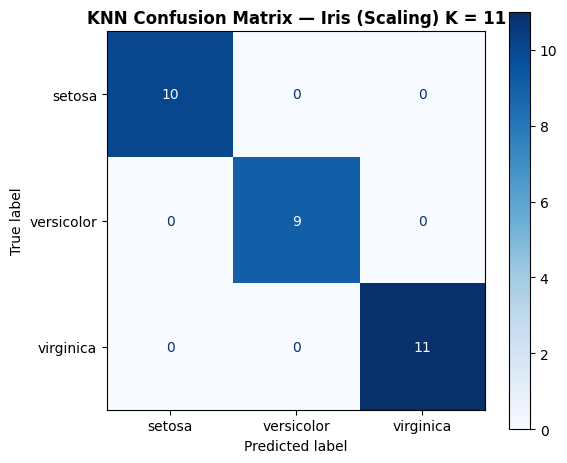

In [99]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_k_11)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('KNN Confusion Matrix — Iris (Scaling) K = 11', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

KNN Classifier Accuracies with and without Scaling:
   n_neighbors  Accuracy (No Scaling)  Accuracy (Scaling)
0            3               1.000000                 1.0
1            5               1.000000                 1.0
2            7               0.966667                 1.0
3            9               1.000000                 1.0
4           11               1.000000                 1.0


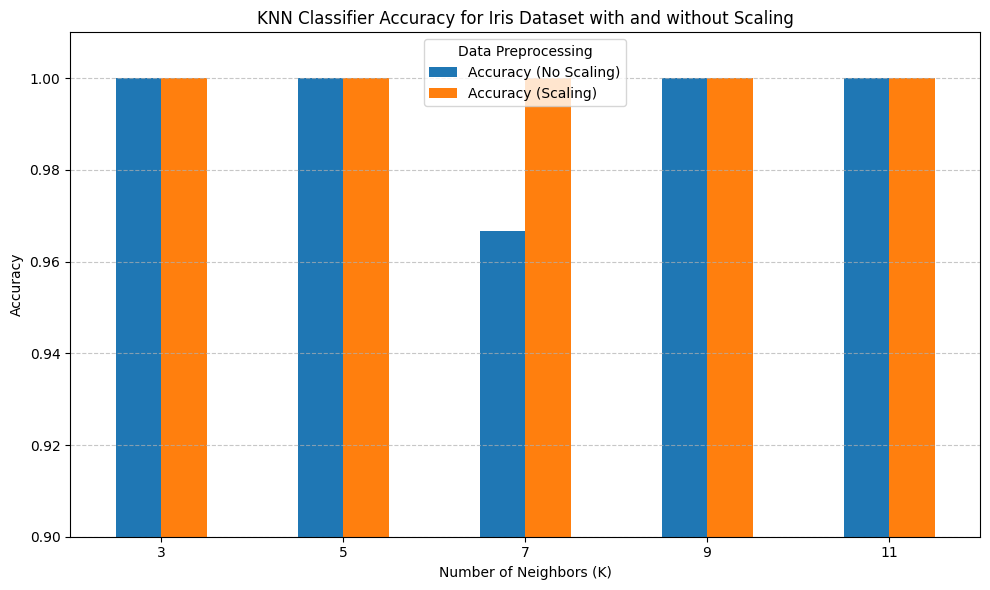

In [100]:
k_values = [3, 5, 7, 9, 11]

# Re-split data to get unscaled versions for accurate comparison
X_train_unscaled, X_test_unscaled, y_train_unscaled, y_test_unscaled = train_test_split(X, y, test_size=0.2, random_state=42)

unscaled_accuracies = []
scaled_accuracies = []

# Calculate accuracies for unscaled data
for k in k_values:
    model_unscaled = KNeighborsClassifier(n_neighbors=k)
    model_unscaled.fit(X_train_unscaled, y_train_unscaled)
    y_pred_unscaled = model_unscaled.predict(X_test_unscaled)
    unscaled_accuracies.append(accuracy_score(y_test_unscaled, y_pred_unscaled))

# Calculate accuracies for scaled data (using the already scaled X_train, X_test)
# The variables X_train, X_test, y_train, y_test in the kernel state are already scaled.
for k in k_values:
    model_scaled = KNeighborsClassifier(n_neighbors=k)
    model_scaled.fit(X_train, y_train)
    y_pred_scaled = model_scaled.predict(X_test)
    scaled_accuracies.append(accuracy_score(y_test, y_pred_scaled))

# Create a DataFrame for the results
results_df = pd.DataFrame({
    'n_neighbors': k_values,
    'Accuracy (No Scaling)': unscaled_accuracies,
    'Accuracy (Scaling)': scaled_accuracies
})

print("KNN Classifier Accuracies with and without Scaling:")
print(results_df)

# Plotting the results
results_df.set_index('n_neighbors').plot(kind='bar', figsize=(10, 6))
plt.title('KNN Classifier Accuracy for Iris Dataset with and without Scaling')
plt.ylabel('Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.xticks(rotation=0)
plt.legend(title='Data Preprocessing')
plt.ylim(0.9, 1.01) # Set y-axis limits to better visualize differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()